# 07 — Final Model Evaluation on the Sealed Test Set
**RouteRight AI — IT Support Ticket Reassignment Risk Prediction**

**Owner:** *(write team member name / ID here)*

This is the **only** notebook that touches `test.csv`. It evaluates the **single final model** chosen in `06e` — nothing else is compared, tuned or re-selected here.

| Rule | Why |
|---|---|
| The model, its hyperparameters, its feature list and its 0.5 decision threshold are **fixed before** the test set is opened | Anything chosen after looking at test results would make the test score optimistic |
| Alternative operating thresholds are chosen **from out-of-fold predictions on the training data**, then applied to test once | Choosing a threshold on test would be tuning on the test set |
| A small lock file records that the test set has been used | A soft guard against re-running with a different model and quietly "peeking" |
| One **pre-declared robustness check** (same model without `opened_month`) is scored alongside the main result | It is reported as a sensitivity analysis, **not** used to pick or change the final model |

**What to keep in mind when reading the numbers (documented earlier in the project):**
* Test positive rate is lower than train (≈ 37% vs ≈ 47%) — the **target drift** — so accuracy is not comparable between train and test; PR-AUC is judged against the *test* no-skill line.
* About 93% of test rows are from **May**; the rest (≈ 274 rows) are spread over other months. The test set is effectively "late May plus a thin tail".
* The cross-validation score of the final model was the *best of 40 candidates* on the same folds, so it is slightly optimistic. A test score somewhat below it is expected.

## 1. Setup and load the final model

In [1]:
import json
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score, brier_score_loss,
                             confusion_matrix, f1_score, matthews_corrcoef, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score, roc_curve)

import baseline_common as bc
import tuning_common as tc

warnings.filterwarnings("ignore")
ROOT = bc.ROOT
FINAL_DIR = ROOT / "models" / "final"
TEST_PATH = ROOT / "data" / "processed" / "test.csv"
EVAL_DIR = ROOT / "docs" / "deliverables_eval2" / "evaluation"
EVAL_DIR.mkdir(parents=True, exist_ok=True)
TARGET = bc.TARGET
RNG_SEED = 42

meta_path, model_path = FINAL_DIR / "final_model_meta.json", FINAL_DIR / "final_model.pkl"
if not (meta_path.exists() and model_path.exists()):
    raise FileNotFoundError("final_model.pkl / final_model_meta.json not found in models/final/. "
                            "Run 06e (final model selection) first.")
meta = json.loads(meta_path.read_text())
model = joblib.load(model_path)
FEATURES = meta["feature_columns"]
THRESHOLD = meta["decision_threshold"]

print("Final model        :", meta["model"])
print("Hyperparameters    :", meta["hyperparameters"])
print("Features used      :", len(FEATURES), "| dropped:", meta["dropped_features"] or "none")
print("Decision threshold :", THRESHOLD)
print(f"CV estimate (train): PR-AUC {meta['cv_pr_auc_mean']} ± {meta['cv_pr_auc_std']} | F1 {meta['cv_f1_mean']} | accuracy {meta['cv_accuracy_mean']}")

Final model        : Random Forest
Hyperparameters    : {'n_estimators': 500, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced'}
Features used      : 109 | dropped: none
Decision threshold : 0.5
CV estimate (train): PR-AUC 0.7611 ± 0.0527 | F1 0.6802 | accuracy 0.7216


### Test-set usage guard

In [2]:
LOCK = EVAL_DIR / "TEST_SET_USED.json"
prev = json.loads(LOCK.read_text()) if LOCK.exists() else None
if prev is None:
    print("First evaluation on the test set with this project. OK.")
elif prev["model"] == meta["model"] and prev["hyperparameters"] == meta["hyperparameters"] and prev["dropped_features"] == meta["dropped_features"]:
    print(f"Note: the test set was already evaluated ({prev['n_runs']} run(s), last {prev['last_run']}) with this SAME final model. Re-running to reproduce results is fine.")
else:
    print("WARNING: the test set was previously evaluated with a DIFFERENT model/configuration:")
    print("   previous:", prev["model"], prev["hyperparameters"], "dropped:", prev["dropped_features"])
    print("   now     :", meta["model"], meta["hyperparameters"], "dropped:", meta["dropped_features"])
    print("   Changing the model after seeing test results makes the test score optimistic. State this in the report.")

First evaluation on the test set with this project. OK.


## 2. Load the test set and check it

In [3]:
train_cols = list(pd.read_csv(bc.TRAIN_PATH, nrows=0).columns)
test = pd.read_csv(TEST_PATH)
assert list(test.columns) == train_cols, "test.csv columns differ from train.csv"
assert not [c for c in FEATURES if c not in test.columns], "final model expects columns missing from test.csv"
assert test.isna().sum().sum() == 0, "test.csv contains missing values"

X_test, y_test = test[FEATURES], test[TARGET].astype(int)
train_pos_rate = pd.read_csv(bc.TRAIN_PATH, usecols=[TARGET])[TARGET].mean()
test_pos_rate = y_test.mean()

print("Test shape:", test.shape, "| features fed to the model:", X_test.shape[1])
print(f"Positive rate  train {train_pos_rate:.4f}  vs  test {test_pos_rate:.4f}  (drift {test_pos_rate - train_pos_rate:+.4f})")
month_counts = test["opened_month"].value_counts().sort_index()
may_share = (test["opened_month"] == 5).mean()
print(f"Share of test rows from May: {may_share:.1%}")
print("Rows per opened_month:", month_counts.astype(int).to_dict())

Test shape: (3738, 110) | features fed to the model: 109
Positive rate  train 0.4712  vs  test 0.3713  (drift -0.0999)
Share of test rows from May: 92.7%
Rows per opened_month: {1.0: 94, 2.0: 55, 5.0: 3464, 6.0: 5, 7.0: 14, 8.0: 15, 9.0: 12, 10.0: 16, 11.0: 26, 12.0: 37}


## 3. Predictions and headline metrics (decision threshold fixed in advance)

In [4]:
proba = model.predict_proba(X_test)[:, 1]

def metrics_at(y, p, thr):
    pred = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {"threshold": thr, "accuracy": accuracy_score(y, pred), "balanced_accuracy": balanced_accuracy_score(y, pred),
            "precision": precision_score(y, pred, zero_division=0), "recall": recall_score(y, pred, zero_division=0),
            "specificity": tn / (tn + fp) if (tn + fp) else np.nan, "f1": f1_score(y, pred, zero_division=0),
            "mcc": matthews_corrcoef(y, pred), "roc_auc": roc_auc_score(y, p), "pr_auc": average_precision_score(y, p),
            "brier": brier_score_loss(y, p), "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}

m = metrics_at(y_test, proba, THRESHOLD)
headline = pd.Series({k: m[k] for k in ["pr_auc", "f1", "recall", "precision", "accuracy", "balanced_accuracy",
                                         "specificity", "roc_auc", "mcc", "brier"]}).round(4).to_frame("test")

ref = pd.DataFrame({"no-skill reference": {"pr_auc": test_pos_rate, "accuracy": 1 - test_pos_rate, "roc_auc": 0.5}})
cv = pd.DataFrame({"cv_estimate (train)": {"pr_auc": meta["cv_pr_auc_mean"], "f1": meta["cv_f1_mean"], "accuracy": meta["cv_accuracy_mean"]}})
table = headline.join(cv).join(ref)
table["test - cv"] = (table["test"] - table["cv_estimate (train)"]).round(4)
print(f"Final model: {meta['model']} | threshold {THRESHOLD}")
table

Final model: Random Forest | threshold 0.5


,test,cv_estimate (train),no-skill reference,test - cv
pr_auc,0.7559,0.7611,0.371322,-0.0052
f1,0.6793,0.6802,NaN,-0.0009
recall,0.7111,NaN,NaN,NaN
precision,0.6502,NaN,NaN,NaN
accuracy,0.7507,0.7216,0.628678,0.0291
balanced_accuracy,0.7426,NaN,NaN,NaN
specificity,0.7740,NaN,NaN,NaN
roc_auc,0.8226,NaN,0.500000,NaN
mcc,0.4773,NaN,NaN,NaN
brier,0.1688,NaN,NaN,NaN


**How to read this table**
* `no-skill reference`: PR-AUC of a model with no information equals the test positive rate; accuracy of always predicting "no reassignment" equals 1 − positive rate. The model should clearly beat both.
* `test - cv`: expected to be slightly negative (CV was the best of 40 candidates, and the test period is a different slice of time). A gap this size does not by itself indicate a bug.
* Accuracy is **not** comparable between train/CV (≈ 47% positive) and test (≈ 37% positive).

### Uncertainty: bootstrap 95% confidence intervals

In [5]:
rng = np.random.RandomState(RNG_SEED)
yv, n, B = y_test.values, len(y_test), 1000
boot = {k: [] for k in ["pr_auc", "roc_auc", "f1", "recall", "precision", "accuracy"]}
for _ in range(B):
    i = rng.randint(0, n, n)
    yb, pb = yv[i], proba[i]
    pr = (pb >= THRESHOLD).astype(int)
    boot["pr_auc"].append(average_precision_score(yb, pb)); boot["roc_auc"].append(roc_auc_score(yb, pb))
    boot["f1"].append(f1_score(yb, pr, zero_division=0)); boot["recall"].append(recall_score(yb, pr, zero_division=0))
    boot["precision"].append(precision_score(yb, pr, zero_division=0)); boot["accuracy"].append(accuracy_score(yb, pr))
ci = pd.DataFrame({k: {"estimate": m[k], "ci_low": np.percentile(v, 2.5), "ci_high": np.percentile(v, 97.5)} for k, v in boot.items()}).T.round(4)
ci

,estimate,ci_low,ci_high
pr_auc,0.7559,0.7350,0.7757
roc_auc,0.8226,0.8088,0.8352
f1,0.6793,0.6585,0.6979
recall,0.7111,0.6882,0.7346
precision,0.6502,0.6270,0.6727
accuracy,0.7507,0.7373,0.7640


## 4. Confusion matrix — what the errors mean for the service desk

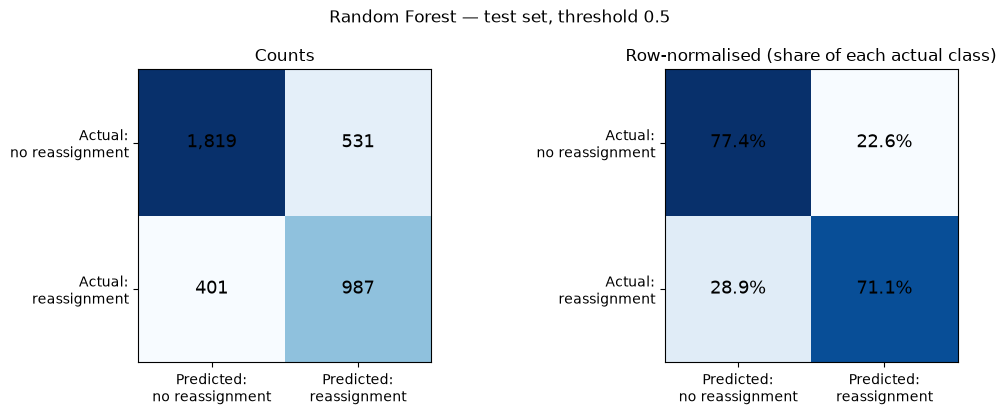

False negatives (reassigned tickets the model did NOT flag): 401  -> missed chances for early review
False positives (tickets flagged that were NOT reassigned) : 531  -> unnecessary review work


In [6]:
cm = np.array([[m["tn"], m["fp"]], [m["fn"], m["tp"]]])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, data, title, fmt in [(axes[0], cm, "Counts", "{:,.0f}"), (axes[1], cm / cm.sum(axis=1, keepdims=True), "Row-normalised (share of each actual class)", "{:.1%}")]:
    ax.imshow(data, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, fmt.format(data[i, j]), ha="center", va="center", fontsize=13, color="black")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Predicted:\nno reassignment", "Predicted:\nreassignment"]); ax.set_yticklabels(["Actual:\nno reassignment", "Actual:\nreassignment"])
    ax.set_title(title)
plt.suptitle(f"{meta['model']} — test set, threshold {THRESHOLD}")
plt.tight_layout(); plt.savefig(EVAL_DIR / "test_confusion_matrix.png", dpi=130); plt.show()

print(f"False negatives (reassigned tickets the model did NOT flag): {m['fn']:,}  -> missed chances for early review")
print(f"False positives (tickets flagged that were NOT reassigned) : {m['fp']:,}  -> unnecessary review work")

## 5. Curves: ROC, precision–recall, calibration, score distribution

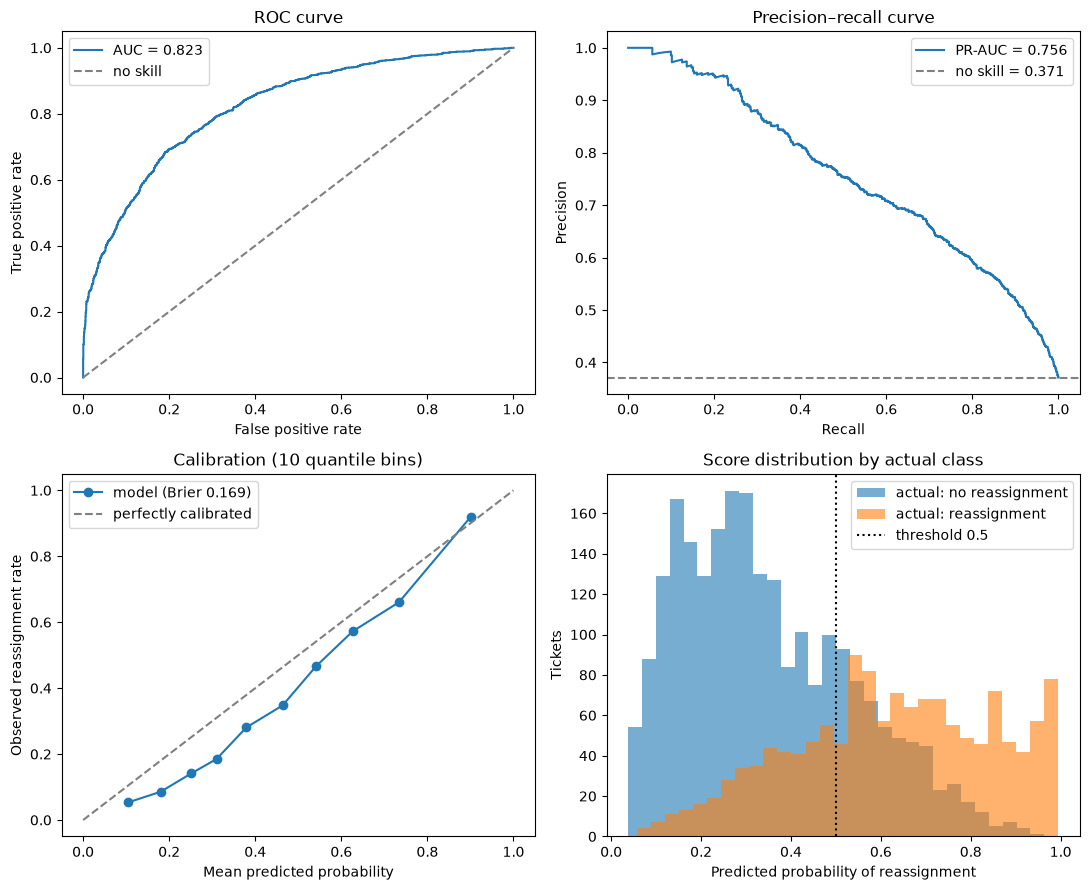

In [7]:
fpr, tpr, _ = roc_curve(y_test, proba)
prec, rec, _ = precision_recall_curve(y_test, proba)
frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes[0, 0].plot(fpr, tpr, label=f"AUC = {m['roc_auc']:.3f}"); axes[0, 0].plot([0, 1], [0, 1], "--", color="grey", label="no skill")
axes[0, 0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curve"); axes[0, 0].legend()
axes[0, 1].plot(rec, prec, label=f"PR-AUC = {m['pr_auc']:.3f}"); axes[0, 1].axhline(test_pos_rate, ls="--", color="grey", label=f"no skill = {test_pos_rate:.3f}")
axes[0, 1].set(xlabel="Recall", ylabel="Precision", title="Precision–recall curve"); axes[0, 1].legend()
axes[1, 0].plot(mean_pred, frac_pos, "o-", label=f"model (Brier {m['brier']:.3f})"); axes[1, 0].plot([0, 1], [0, 1], "--", color="grey", label="perfectly calibrated")
axes[1, 0].set(xlabel="Mean predicted probability", ylabel="Observed reassignment rate", title="Calibration (10 quantile bins)"); axes[1, 0].legend()
axes[1, 1].hist(proba[y_test == 0], bins=30, alpha=0.6, label="actual: no reassignment"); axes[1, 1].hist(proba[y_test == 1], bins=30, alpha=0.6, label="actual: reassignment")
axes[1, 1].axvline(THRESHOLD, color="black", ls=":", label=f"threshold {THRESHOLD}")
axes[1, 1].set(xlabel="Predicted probability of reassignment", ylabel="Tickets", title="Score distribution by actual class"); axes[1, 1].legend()
plt.tight_layout(); plt.savefig(EVAL_DIR / "test_curves.png", dpi=130); plt.show()

**Calibration matters for the interface.** The proposal says a risk score will be shown "where appropriately validated". If the calibration curve lies far from the diagonal, the probability should be shown as a **relative risk band (LOW/HIGH)**, not as a literal percentage. Class weighting (`balanced`) deliberately shifts probabilities upward, so a weighted model is usually *not* calibrated even when it ranks tickets well.

## 6. Choosing an operating threshold — **without** using the test set
A fixed 0.5 is a default, not necessarily the best trade-off between missed reassignments (recall) and unnecessary reviews (precision). To explore alternatives fairly, thresholds are chosen from the **out-of-fold predictions on the training data** (same `TimeSeriesSplit` as the rest of the project, refitting the final configuration on each fold), and then applied to the test set **once**.

*Caveat:* out-of-fold rows exclude the first block of training data and have a different positive rate from test, so the chosen thresholds are reasonable starting points rather than guaranteed optima.

In [8]:
def build_final_estimator():
    est = tc.build_estimator(meta["model"])
    prefix = "clf__" if meta["model"] == "Logistic Regression" else ""
    return est.set_params(**{prefix + k: v for k, v in meta["hyperparameters"].items()})

train = pd.read_csv(bc.TRAIN_PATH)
Xtr, ytr = train[FEATURES], train[TARGET].astype(int)
oof_idx, oof_p = [], []
for tr_i, va_i in bc.get_cv().split(Xtr):
    est = clone(build_final_estimator()).fit(Xtr.iloc[tr_i], ytr.iloc[tr_i])
    oof_idx.append(va_i); oof_p.append(est.predict_proba(Xtr.iloc[va_i])[:, 1])
oof_idx, oof_p = np.concatenate(oof_idx), np.concatenate(oof_p)
oof_y = ytr.iloc[oof_idx].values

grid = np.round(np.arange(0.20, 0.801, 0.01), 2)
rows = []
for t in grid:
    pr = (oof_p >= t).astype(int)
    rows.append({"threshold": t, "precision": precision_score(oof_y, pr, zero_division=0),
                 "recall": recall_score(oof_y, pr, zero_division=0), "f1": f1_score(oof_y, pr, zero_division=0)})
oof_curve = pd.DataFrame(rows)

t_f1 = float(oof_curve.loc[oof_curve["f1"].idxmax(), "threshold"])
ok = oof_curve[oof_curve["recall"] >= 0.80]
t_rec80 = float(ok["threshold"].max()) if len(ok) else None      # highest threshold that still keeps recall >= 0.80
candidates = [("default", THRESHOLD), ("max F1 on training OOF", t_f1)] + ([("recall >= 0.80 on training OOF", t_rec80)] if t_rec80 is not None else [])

res = []
for label, t in candidates:
    pr_oof = (oof_p >= t).astype(int)
    mt = metrics_at(y_test, proba, t)
    res.append({"rule": label, "threshold": t,
                "oof_precision": precision_score(oof_y, pr_oof, zero_division=0), "oof_recall": recall_score(oof_y, pr_oof, zero_division=0),
                "test_precision": mt["precision"], "test_recall": mt["recall"], "test_f1": mt["f1"], "test_accuracy": mt["accuracy"],
                "test_flagged_share": (proba >= t).mean()})
threshold_table = pd.DataFrame(res).round(4)
threshold_table

,rule,threshold,oof_precision,oof_recall,test_precision,test_recall,test_f1,test_accuracy,test_flagged_share
0,default,0.50,0.6975,0.6855,0.6502,0.7111,0.6793,0.7507,0.4061
1,max F1 on training OOF,0.42,0.6400,0.8023,0.5929,0.7997,0.6810,0.7218,0.5008
2,recall >= 0.80 on training OOF,0.42,0.6400,0.8023,0.5929,0.7997,0.6810,0.7218,0.5008


**Reading this table:** compare `oof_*` (what the rule achieved on training folds) with `test_*` (what happened on the sealed test set). If recall drops sharply from OOF to test, the drift is hurting the minority-class detection. `test_flagged_share` is the share of all tickets that would be sent for extra review — the operational workload.

## 7. Does the risk score help prioritise review? (gain / lift)

,review_top_share,tickets_reviewed,reassigned_among_reviewed,precision,share_of_all_reassignments_caught,lift_vs_random
0,10%,374,344,0.920,0.248,2.477
1,20%,748,591,0.790,0.426,2.128
2,30%,1121,805,0.718,0.580,1.934
3,40%,1495,979,0.655,0.705,1.764
4,50%,1869,1109,0.593,0.799,1.598


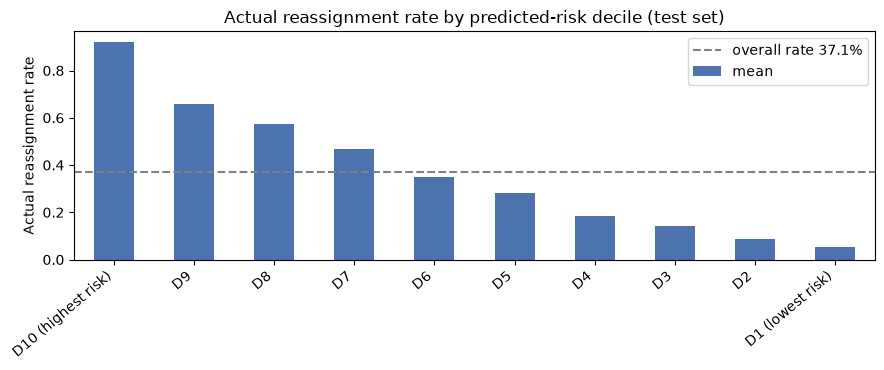

In [9]:
order = np.argsort(-proba)
ys = y_test.values[order]
rows = []
for share in [0.10, 0.20, 0.30, 0.40, 0.50]:
    k = int(round(share * len(ys)))
    caught = ys[:k].sum()
    rows.append({"review_top_share": f"{share:.0%}", "tickets_reviewed": k, "reassigned_among_reviewed": int(caught),
                 "precision": caught / k, "share_of_all_reassignments_caught": caught / ys.sum(), "lift_vs_random": (caught / k) / test_pos_rate})
gain = pd.DataFrame(rows).round(3)
display(gain)

deciles = pd.qcut(pd.Series(proba).rank(method="first"), 10, labels=False)
dec = pd.DataFrame({"decile": deciles, "y": y_test.values}).groupby("decile")["y"].agg(["mean", "count"]).sort_index(ascending=False)
dec.index = [f"D{10 - i}" + (" (highest risk)" if i == 0 else " (lowest risk)" if i == 9 else "") for i in range(10)]
ax = dec["mean"].plot.bar(figsize=(9, 3.8), color="#4C72B0")
ax.axhline(test_pos_rate, color="grey", ls="--", label=f"overall rate {test_pos_rate:.1%}")
ax.set(ylabel="Actual reassignment rate", title="Actual reassignment rate by predicted-risk decile (test set)"); ax.legend()
plt.xticks(rotation=40, ha="right"); plt.tight_layout(); plt.savefig(EVAL_DIR / "test_risk_deciles.png", dpi=130); plt.show()

This is the most business-relevant view: if reviewers check only the **top 20–30% highest-risk tickets**, how many of the eventual reassignments do they catch compared with picking tickets at random (`lift_vs_random` = 1.0)? A clear staircase across deciles means the score ranks tickets usefully even if individual predictions are imperfect.

## 8. Where does the model work better or worse? (segments)

In [10]:
def seg_metrics(mask):
    yy, pp = y_test.values[mask], proba[mask]
    out = {"n": int(mask.sum()), "positive_rate": yy.mean()}
    if 0 < yy.sum() < len(yy):
        pr = (pp >= THRESHOLD).astype(int)
        out.update({"precision": precision_score(yy, pr, zero_division=0), "recall": recall_score(yy, pr, zero_division=0),
                    "f1": f1_score(yy, pr, zero_division=0), "pr_auc": average_precision_score(yy, pp), "accuracy": accuracy_score(yy, pr)})
    return out

is_may = (test["opened_month"] == 5).values
by_month = pd.DataFrame({"May (bulk of test)": seg_metrics(is_may), "All other months (thin tail)": seg_metrics(~is_may)}).T.round(3)
display(by_month)

ag_cols = [c for c in test.columns if c.startswith("assignment_group_")]
ag = test[ag_cols].idxmax(axis=1).str.replace("assignment_group_", "", regex=False)
top_groups = ag.value_counts().loc[lambda s: s >= 50].head(8).index
seg = pd.DataFrame({f"group {g}": seg_metrics((ag == g).values) for g in top_groups}).T.round(3)
seg

,n,positive_rate,precision,recall,f1,pr_auc,accuracy
May (bulk of test),3464.0,0.363,0.68,0.697,0.689,0.777,0.771
All other months (thin tail),274.0,0.474,0.48,0.846,0.613,0.549,0.493


,n,positive_rate,precision,recall,f1,pr_auc,accuracy
group 70,1960.0,0.254,0.599,0.578,0.588,0.627,0.794
group Other,615.0,0.439,0.536,0.656,0.590,0.630,0.600
group 20,225.0,0.956,0.956,1.000,0.977,0.990,0.956
group 65,139.0,0.626,0.640,0.920,0.755,0.764,0.626
group 25,94.0,0.191,0.667,0.333,0.444,0.554,0.840
group 24,94.0,0.266,0.737,0.560,0.636,0.751,0.830
group 57,79.0,0.595,0.592,0.894,0.712,0.627,0.570
group 73,71.0,0.268,0.667,0.316,0.429,0.504,0.775


Treat small segments with caution (the non-May tail and any group with a few dozen tickets): their metrics have wide uncertainty. Large differences between assignment groups are worth reporting as a limitation — they show the model's reliability is not uniform across the organisation.

## 9. Pre-declared robustness check — does the model depend on `opened_month`?
`opened_month` works as a **time index**: the training data covers only Feb–May 2016, so the feature cannot carry over to months the model has never seen (the test set contains January and June–December rows). The cross-validation experiments in `06e` showed that dropping it costs the tree models roughly 0.01–0.02 PR-AUC. The team decided (before opening the test set) to **keep all features in the final model** and to report this check instead.

The same hyperparameters are refit on the training data **without** `opened_month` and scored once on the test set. This is a sensitivity analysis: whatever the outcome, the final model stays as chosen in `06e`.

In [11]:
SENS_DROP = ["opened_month"]
if not all(c in FEATURES for c in SENS_DROP):
    print("Skipped: the final model was already trained without", SENS_DROP)
    sens = None
else:
    sens_features = [c for c in FEATURES if c not in SENS_DROP]
    sens_model = clone(build_final_estimator()).fit(Xtr[sens_features], ytr)
    proba_s = sens_model.predict_proba(test[sens_features])[:, 1]
    ms = metrics_at(y_test, proba_s, THRESHOLD)
    cols = ["pr_auc", "roc_auc", "f1", "recall", "precision", "accuracy"]
    sens = pd.DataFrame({"primary (all features)": {k: m[k] for k in cols},
                         "sensitivity (no opened_month)": {k: ms[k] for k in cols}})
    sens["difference (primary - sensitivity)"] = sens["primary (all features)"] - sens["sensitivity (no opened_month)"]

    # paired bootstrap: same resampled tickets for both models, so the difference is not inflated by sampling noise
    rng2 = np.random.RandomState(RNG_SEED)
    diffs = []
    for _ in range(1000):
        i = rng2.randint(0, len(yv), len(yv))
        diffs.append(average_precision_score(yv[i], proba[i]) - average_precision_score(yv[i], proba_s[i]))
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    print(f"PR-AUC difference (primary - no month): {m['pr_auc'] - ms['pr_auc']:+.4f}  (paired bootstrap 95% CI {lo:+.4f} to {hi:+.4f})")
    print("Interval excludes 0 -> the month feature makes a measurable difference on this test set." if (lo > 0 or hi < 0)
          else "Interval includes 0 -> no measurable difference on this test set.")
    sens = sens.round(4)
sens

PR-AUC difference (primary - no month): +0.0207  (paired bootstrap 95% CI +0.0140 to +0.0278)
Interval excludes 0 -> the month feature makes a measurable difference on this test set.


,primary (all features),sensitivity (no opened_month),difference (primary - sensitivity)
pr_auc,0.7559,0.7352,0.0207
roc_auc,0.8226,0.8088,0.0137
f1,0.6793,0.6754,0.0039
recall,0.7111,0.7608,-0.0497
precision,0.6502,0.6072,0.0430
accuracy,0.7507,0.7285,0.0222


**How to read this:** the test set is ~93% May, which is inside the training months, so the month feature is expected to help here. That is exactly why this check cannot prove the feature is safe for a deployed system running in later months. Report the result honestly: if the two models are close, the dependence is small; if the primary is clearly better, say that part of its advantage comes from a time signal that will not generalise.

## 10. Save outputs and plain-language summary

In [12]:
final_report = {
    "model": meta["model"], "hyperparameters": meta["hyperparameters"], "dropped_features": meta["dropped_features"],
    "n_features": len(FEATURES), "decision_threshold": THRESHOLD, "n_test": int(len(y_test)),
    "test_positive_rate": float(test_pos_rate), "train_positive_rate": float(train_pos_rate), "may_share_of_test": float(may_share),
    "test_metrics": {k: (float(v) if not isinstance(v, int) else v) for k, v in m.items()},
    "bootstrap_95ci": ci.to_dict(orient="index"),
    "cv_estimate": {"pr_auc": meta["cv_pr_auc_mean"], "pr_auc_std": meta["cv_pr_auc_std"], "f1": meta["cv_f1_mean"], "accuracy": meta["cv_accuracy_mean"]},
    "sensitivity_no_opened_month": (sens.to_dict(orient="index") if sens is not None else None),
    "evaluated_at": datetime.now().isoformat(timespec="seconds")}
(EVAL_DIR / "test_metrics.json").write_text(json.dumps(final_report, indent=2, default=str))
table.to_csv(EVAL_DIR / "test_metrics_table.csv"); ci.to_csv(EVAL_DIR / "test_bootstrap_ci.csv")
threshold_table.to_csv(EVAL_DIR / "test_threshold_options.csv", index=False)
if sens is not None:
    sens.to_csv(EVAL_DIR / "test_sensitivity_no_month.csv")
gain.to_csv(EVAL_DIR / "test_gain_table.csv", index=False); by_month.to_csv(EVAL_DIR / "test_segments_month.csv"); seg.to_csv(EVAL_DIR / "test_segments_assignment_group.csv")
pd.DataFrame({"row_index": np.arange(len(y_test)), "y_true": y_test.values, "proba": proba, "y_pred": (proba >= THRESHOLD).astype(int)}).to_csv(EVAL_DIR / "test_predictions.csv", index=False)

LOCK.write_text(json.dumps({"model": meta["model"], "hyperparameters": meta["hyperparameters"], "dropped_features": meta["dropped_features"],
                            "first_run": prev["first_run"] if prev else datetime.now().isoformat(timespec="seconds"),
                            "last_run": datetime.now().isoformat(timespec="seconds"), "n_runs": (prev["n_runs"] + 1) if prev else 1}, indent=2))

top20 = gain.loc[gain["review_top_share"] == "20%"].iloc[0]
print(f"SUMMARY ({meta['model']}, threshold {THRESHOLD}) on {len(y_test):,} unseen tickets, {test_pos_rate:.1%} of which were reassigned:")
print(f"  * Ranking quality: PR-AUC {m['pr_auc']:.3f} (95% CI {ci.loc['pr_auc','ci_low']:.3f}-{ci.loc['pr_auc','ci_high']:.3f}) vs {test_pos_rate:.3f} for a no-skill model; ROC-AUC {m['roc_auc']:.3f}.")
print(f"  * At the default threshold it catches {m['recall']:.1%} of reassigned tickets (recall) with {m['precision']:.1%} of its flags correct (precision); F1 {m['f1']:.3f}, accuracy {m['accuracy']:.1%}.")
print(f"  * Reviewing only the riskiest 20% of tickets catches {top20['share_of_all_reassignments_caught']:.1%} of all reassignments (lift {top20['lift_vs_random']:.2f}x over random).")
print(f"  * Compared with the cross-validation estimate, PR-AUC changed by {m['pr_auc'] - meta['cv_pr_auc_mean']:+.3f} (some drop is expected: CV was the best of 40 candidates and the test period differs).")
if sens is not None:
    print(f"  * Robustness: without opened_month, PR-AUC is {ms['pr_auc']:.3f} vs {m['pr_auc']:.3f} with it (difference {m['pr_auc'] - ms['pr_auc']:+.3f}).")
print("Saved to:", EVAL_DIR)

SUMMARY (Random Forest, threshold 0.5) on 3,738 unseen tickets, 37.1% of which were reassigned:
  * Ranking quality: PR-AUC 0.756 (95% CI 0.735-0.776) vs 0.371 for a no-skill model; ROC-AUC 0.823.
  * At the default threshold it catches 71.1% of reassigned tickets (recall) with 65.0% of its flags correct (precision); F1 0.679, accuracy 75.1%.
  * Reviewing only the riskiest 20% of tickets catches 42.6% of all reassignments (lift 2.13x over random).
  * Compared with the cross-validation estimate, PR-AUC changed by -0.005 (some drop is expected: CV was the best of 40 candidates and the test period differs).
  * Robustness: without opened_month, PR-AUC is 0.735 vs 0.756 with it (difference +0.021).
Saved to: C:\Users\LOQ\OneDrive\Documents\GitHub\routeright-reassignment-predictor\docs\deliverables_eval2\evaluation


## 11. Interpretation and limitations (complete after running)

Use the printed summary and tables above to write the report's evaluation section. Points to address, each backed by a number from this notebook:

1. **Does the model beat no-skill?** Compare PR-AUC with the test positive rate, and accuracy with the "always no" accuracy.
2. **Generalisation:** how far is each test metric from its CV estimate, and is that within the bootstrap interval? Explain the likely causes (selection optimism, target drift, different time slice).
3. **Error profile:** missed reassignments (false negatives) versus unnecessary reviews (false positives), and which matters more for the service desk.
4. **Operating threshold:** whether the OOF-chosen alternatives improved the trade-off on test, and what share of tickets each would send for review.
5. **Practical value:** the gain/lift table — what review effort catches what share of reassignments.
6. **Calibration:** whether the interface should show a probability or only a LOW/HIGH band.
7. **Segments:** where performance is weak (small groups, non-May months).
8. **Robustness to `opened_month`:** report the sensitivity result and what it implies for use in months outside Feb–May.
9. **Limitations to state:** target drift (47% → 37%), May-heavy test set with months unseen in training, single organisation, 1,865 duplicate training rows that make CV slightly optimistic, one test split (hence the bootstrap intervals), and the model being **decision support only**.